In [ ]:
# Using Chemical Language transformer model for Molecular Property prediction
# ADME (Absorption, Distribution, Metabolism, and Excretion) 

In [ ]:
# https://dmol.pub/dl/gnn.html : Graph Neural Networks

In [ ]:
# https://www.nature.com/articles/s41467-023-38192-3

In [ ]:
# https://medium.com/@tejpal.abhyuday/application-of-gnn-for-calculating-the-solubility-of-molecule-graph-level-prediction-8bac5fabf600

In [ ]:
# https://medium.com/@nikopavl4/pytorch-geometric-for-graph-based-molecular-property-prediction-using-moleculenet-benchmark-41e36369d3c6

In [ ]:
# https://pharmanalytics.medium.com/using-chemical-language-transformer-model-for-molecular-property-prediction-regression-tasks-5d617aba4639

In [ ]:
# https://medium.com/@mulugetas/drug-discovery-and-graph-neural-networks-gnns-a-regression-example-fc738e0f11f3

In [ ]:
# MOLECULE NET : https://moleculenet.org/

In [ ]:
# https://arxiv.org/abs/1703.00564

In [ ]:
# DEEPCHEM
# https://github.com/deepchem/deepchem

In [ ]:
# MoleculeNet is built upon multiple public databases. 
# The full collection currently includes over 700,000 compounds tested on a range of different properties. 
# We test the performances of various machine learning models with different featurizations on the datasets 
# (detailed descriptions here), with all results reported in AUC-ROC, AUC-PRC, RMSE and MAE scores.

In [ ]:
# https://medium.com/data-science/drug-discovery-with-graph-neural-networks-part-1-1011713185eb

In [5]:
print("Drug Discovery with Graph Neural Networks — part 1")

Drug Discovery with Graph Neural Networks — part 1


In [ ]:
# Why Molecular Solubility is Important #  whether the drug can reach efficiently the patient’s bloodstream

In [ ]:
# SMILES
# Fingerprints

In [6]:
print('''Adjacency Matrix :

Another way to preprocess a molecular structure is to create an adjacency matrix. 
# The adjacency matrix contains information about the connectivity of atoms, 
# where “1” means that there is a connection between them and “0” that there is none.

''')

Adjacency Matrix :

Another way to preprocess a molecular structure is to create an adjacency matrix. 
# The adjacency matrix contains information about the connectivity of atoms, 
# where “1” means that there is a connection between them and “0” that there is none.




In [ ]:
print('''Feature Vectors :

Individual feature vector, let’s say v0, contains information about specific atom. 
Individual Feature Pair Vector contains information about two neighbouring atoms and 
it is often a function (sum, average, etc. ) of two feature vectors of these individual atoms.

In the feature vector for each atom, there can be information about the atomic number, 
number of valence electrons, or number of single bonds. 

There is of course many more and they can fortunately be generated by RDKit and Deepchem
''')


In [ ]:
# Preprocessing is covered by external libraries such as Deepchem or RDKit.

In [1]:
print('''

Solubility :

The variable that we are going to predict is called cLogP and is also known as octanol-water partition coefficient. 
Basically, the lower is the value the more soluble it is in water. clogP is a log ratio so the values range from -3 to 7 

https://medium.com/data-science/drug-discovery-with-graph-neural-networks-part-1-1011713185eb

''')



Solubility :

The variable that we are going to predict is called cLogP and is also known as octanol-water partition coefficient. 
Basically, the lower is the value the more soluble it is in water. clogP is a log ratio so the values range from -3 to 7 

https://medium.com/data-science/drug-discovery-with-graph-neural-networks-part-1-1011713185eb




In [27]:
print('''

Target Variable : Solubility

The prediction target is described in the notebook as 
cLogP (octanol–water partition coefficient), a common measure of molecular hydrophobicity.

Interpretation:

Lower values → more water-soluble molecules
Higher values → more hydrophobic/lipophilic molecules

Typical values range approximately from: −3≤cLogP≤7

However, an important clarification is that the underlying Delaney dataset actually uses:

logS = log10(molar solubility)

which measures true aqueous solubility rather than partitioning between octanol and water. 

The original notebook and Medium article use somewhat loose terminology and 
occasionally conflate logS and logP, even though they describe related but distinct physicochemical properties.

''')



Target Variable : Solubility

The prediction target is described in the notebook as 
cLogP (octanol–water partition coefficient), a common measure of molecular hydrophobicity.

Interpretation:

Lower values → more water-soluble molecules
Higher values → more hydrophobic/lipophilic molecules

Typical values range approximately from: −3≤cLogP≤7

However, an important clarification is that the underlying Delaney dataset actually uses:

logS = log10(molar solubility)

which measures true aqueous solubility rather than partitioning between octanol and water. 

The original notebook and Medium article use somewhat loose terminology and 
occasionally conflate logS and logP, even though they describe related but distinct physicochemical properties.




In [4]:
# We will download a Delaney dataset, which is considered as a benchmark for solubility prediction task. 
# We then load the dataset using CSVLoader class and specify a column with cLogP data which is passed into tasks argument. 
# In smiles_field, name of the column with SMILES string have to be specified. 
# We choose a ConvMolFeaturizer which will create input features in a format required by the GNN model that we are going to use.

In [ ]:
# https://medium.com/data-science/drug-discovery-with-graph-neural-networks-part-1-1011713185eb

In [5]:
"""
Drug Discovery with Graph Neural Networks — solubility prediction on Delaney
============================================================================

Local adaptation of:
  Kacper Kubara, "Drug Discovery with Graph Neural Networks — part 1"
  (TDS Archive, 2020)

The original article uses DeepChem's GraphConvModel (Duvenaud et al., 2015)
to predict aqueous solubility (cLogP / logS) from the Delaney "ESOL" dataset.

This script:
  1. Loads Delaney directly via DeepChem's MoleculeNet loader (no CSV download
     needed — DeepChem caches it under ~/.deepchem/datasets/).
  2. Featurizes molecules as ConvMol graphs.
  3. Splits with RandomSplitter into train / valid / test (80 / 10 / 10).
  4. Trains a GraphConvModel for solubility regression.
  5. Reports Pearson R² (and RMSE) on train / valid / test.
  6. Plots a predicted-vs-true parity plot.
  7. Saves the trained model and predictions to disk.

Requirements:
  pip install deepchem rdkit
  # Plus ONE of these backends — DeepChem can use either:
  pip install tensorflow            # for the original GraphConvModel
  # OR
  pip install torch torch_geometric # for the PyTorch alternative (AttentiveFP)

Toggle BACKEND below depending on which you have installed.
"""

'\nDrug Discovery with Graph Neural Networks — solubility prediction on Delaney\n============================================================================\n\nLocal adaptation of:\n  Kacper Kubara, "Drug Discovery with Graph Neural Networks — part 1"\n  (TDS Archive, 2020)\n\nThe original article uses DeepChem\'s GraphConvModel (Duvenaud et al., 2015)\nto predict aqueous solubility (cLogP / logS) from the Delaney "ESOL" dataset.\n\nThis script:\n  1. Loads Delaney directly via DeepChem\'s MoleculeNet loader (no CSV download\n     needed — DeepChem caches it under ~/.deepchem/datasets/).\n  2. Featurizes molecules as ConvMol graphs.\n  3. Splits with RandomSplitter into train / valid / test (80 / 10 / 10).\n  4. Trains a GraphConvModel for solubility regression.\n  5. Reports Pearson R² (and RMSE) on train / valid / test.\n  6. Plots a predicted-vs-true parity plot.\n  7. Saves the trained model and predictions to disk.\n\nRequirements:\n  pip install deepchem rdkit\n  # Plus ONE of t

In [ ]:
# Claude converted the code available in :
# https://medium.com/data-science/drug-discovery-with-graph-neural-networks-part-1-1011713185eb

In [7]:
print(''' 

The Delaney dataset (also called ESOL) is the canonical small benchmark for aqueous solubility prediction:
Source: John S. Delaney, "ESOL: Estimating Aqueous Solubility Directly from Molecular Structure,
" J. Chem. Inf. Comput. Sci. 44, 1000–1005 (2004).

Size: 1,128 small organic molecules.

Inputs: SMILES strings (one per molecule).

Target: measured log solubility in mols per litre — i.e. log₁₀(S) where S is in mol/L. 
Values roughly range from about −11.6 (very insoluble) to +1.6 (very soluble).

Why it's popular: small, clean, single-task regression — perfect for prototyping GNNs, 
descriptor-based ML, and Transformer-based models. It's task 1 of MoleculeNet.

''')

 

The Delaney dataset (also called ESOL) is the canonical small benchmark for aqueous solubility prediction:
Source: John S. Delaney, "ESOL: Estimating Aqueous Solubility Directly from Molecular Structure,
" J. Chem. Inf. Comput. Sci. 44, 1000–1005 (2004).

Size: 1,128 small organic molecules.

Inputs: SMILES strings (one per molecule).

Target: measured log solubility in mols per litre — i.e. log₁₀(S) where S is in mol/L. 
Values roughly range from about −11.6 (very insoluble) to +1.6 (very soluble).

Why it's popular: small, clean, single-task regression — perfect for prototyping GNNs, 
descriptor-based ML, and Transformer-based models. It's task 1 of MoleculeNet.




In [8]:
import pandas as pd
import matplotlib.pyplot as plt
 
 
# ---------------------------------------------------------------------------
# Option A — straight CSV (no ML library needed)
# ---------------------------------------------------------------------------
URL = "https://deepchemdata.s3-us-west-1.amazonaws.com/datasets/delaney-processed.csv"
df = pd.read_csv(URL)
 
print("=" * 70)
print("A. Raw CSV from DeepChem S3")
print("=" * 70)
print(f"Shape         : {df.shape}")
print(f"Columns       : {list(df.columns)}")
print()
print("First 5 rows:")
print(df.head().to_string())
print()
print("logS summary statistics:")
print(df["measured log solubility in mols per litre"].describe().to_string())
 
 

A. Raw CSV from DeepChem S3
Shape         : (1128, 10)
Columns       : ['Compound ID', 'ESOL predicted log solubility in mols per litre', 'Minimum Degree', 'Molecular Weight', 'Number of H-Bond Donors', 'Number of Rings', 'Number of Rotatable Bonds', 'Polar Surface Area', 'measured log solubility in mols per litre', 'smiles']

First 5 rows:
  Compound ID  ESOL predicted log solubility in mols per litre  Minimum Degree  Molecular Weight  Number of H-Bond Donors  Number of Rings  Number of Rotatable Bonds  Polar Surface Area  measured log solubility in mols per litre                                                  smiles
0   Amigdalin                                           -0.974               1           457.432                        7                3                          7              202.32                                      -0.77  OCC3OC(OCC2OC(OC(C#N)c1ccccc1)C(O)C(O)C2O)C(O)C(O)C3O 
1    Fenfuram                                           -2.885               1         

In [9]:
# ---------------------------------------------------------------------------
# Option B — through DeepChem's MoleculeNet loader
# ---------------------------------------------------------------------------
# import deepchem as dc
# tasks, datasets, transformers = dc.molnet.load_delaney(
#     featurizer="Raw", splitter=None, reload=True,
# )
# all_ds = datasets[0]                # single un-split dataset when splitter=None
# print(f"\nDeepChem tasks    : {tasks}")
# print(f"DeepChem #mols    : {len(all_ds)}")
# print(f"DeepChem SMILES[:3] = {all_ds.ids[:3]}")
# print(f"DeepChem y[:3]      = {all_ds.y[:3].ravel()}")
 
 
# ---------------------------------------------------------------------------
# Option C — through PyTorch Geometric (graph objects, ready for GNNs)
# ---------------------------------------------------------------------------
# from torch_geometric.datasets import MoleculeNet
# pyg = MoleculeNet(root="./data/MoleculeNet", name="ESOL")
# print(f"\nPyG dataset       : {pyg}")
# print(f"PyG #mols         : {len(pyg)}")
# print(f"PyG atom feats    : {pyg.num_node_features}-dim per atom")
# print(f"PyG bond feats    : {pyg.num_edge_features}-dim per bond")
# d0 = pyg[0]
# print(f"First molecule    : {d0}")
# print(f"  SMILES          : {d0.smiles}")
# print(f"  #atoms          : {d0.num_nodes}")
# print(f"  #bonds          : {d0.num_edges // 2}")    # PyG stores both directions
# print(f"  logS target     : {float(d0.y):.3f}")
 
 
# ---------------------------------------------------------------------------
# Quick visualizations
# ---------------------------------------------------------------------------
y = df["measured log solubility in mols per litre"]
mw = df["Molecular Weight"]
 
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
 
axes[0].hist(y, bins=40, edgecolor="black")
axes[0].set_xlabel("log solubility (mol/L)")
axes[0].set_ylabel("count")
axes[0].set_title("Distribution of logS targets")
 
axes[1].hist(mw, bins=40, edgecolor="black")
axes[1].set_xlabel("Molecular weight (Da)")
axes[1].set_title("Molecular weight distribution")
 
axes[2].scatter(mw, y, alpha=0.5, s=12)
axes[2].set_xlabel("Molecular weight (Da)")
axes[2].set_ylabel("log solubility (mol/L)")
axes[2].set_title("MW vs. logS — bigger usually means less soluble")
 
plt.tight_layout()
plt.savefig("delaney_overview.png", dpi=150)
plt.close(fig)
print("\nSaved figure -> delaney_overview.png")
 


Saved figure -> delaney_overview.png


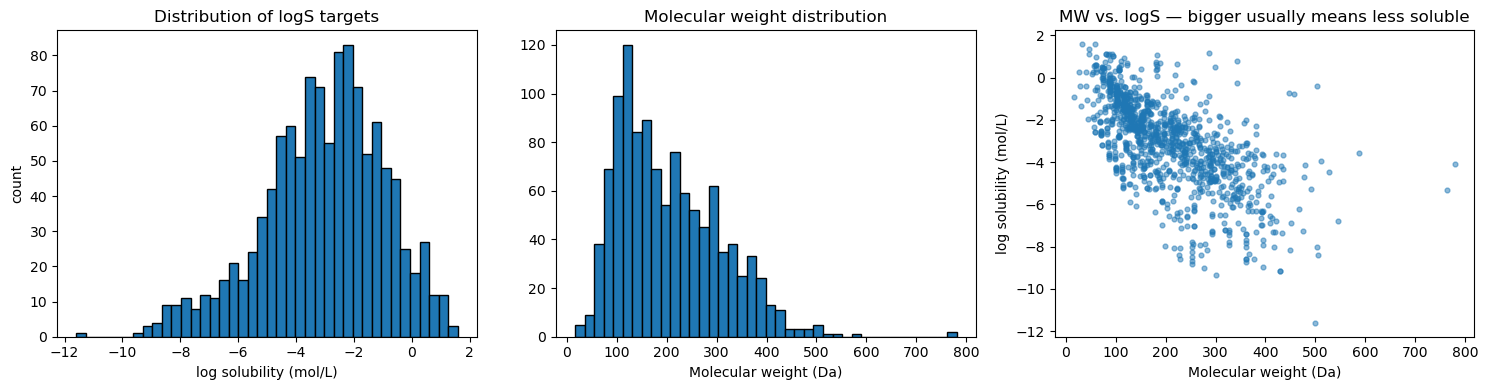

In [11]:
fig

In [17]:
# A few orientation points when you look at the numbers:

# logS = 0 means roughly 1 mol/L solubility (about as soluble as glucose).
# logS ≈ −4 is typical for moderately drug-like molecules.
# logS < −6 is the "very poorly soluble" zone where formulation becomes hard.
# The dataset's average logS is around −3.05 and the standard deviation is roughly 2.10 
# — useful baseline numbers when you're judging RMSE on a model (a model with RMSE ≈ 2.1 is essentially predicting the mean).

In [12]:
# ---------------------------------------------------------------------------
# Look at the most and least soluble molecules
# ---------------------------------------------------------------------------
print("\nTop 5 MOST soluble molecules in the dataset:")
top = df.nlargest(5, "measured log solubility in mols per litre")[
    ["Compound ID", "smiles", "measured log solubility in mols per litre"]
]
print(top.to_string(index=False))
 
print("\nTop 5 LEAST soluble molecules in the dataset:")
bot = df.nsmallest(5, "measured log solubility in mols per litre")[
    ["Compound ID", "smiles", "measured log solubility in mols per litre"]
]
print(bot.to_string(index=False))


Top 5 MOST soluble molecules in the dataset:
     Compound ID                       smiles  measured log solubility in mols per litre
       Acetamide                      CC(=O)N                                      1.580
        Methanol                           CO                                      1.570
Methyl hydrazine                          CNN                                      1.340
     vamidothion CNC(=O)C(C)SCCSP(=O)(OC)(OC)                                      1.144
        Glycerol                     OCC(O)CO                                      1.120

Top 5 LEAST soluble molecules in the dataset:
                 Compound ID                                                smiles  measured log solubility in mols per litre
2,2',3,3',4,4',5,5',6,6'-PCB Clc1c(Cl)c(Cl)c(c(Cl)c1Cl)c2c(Cl)c(Cl)c(Cl)c(Cl)c2Cl                                     -11.600
                    Coronene                c1cc2ccc3ccc4ccc5ccc6ccc1c7c2c3c4c5c67                                     -9

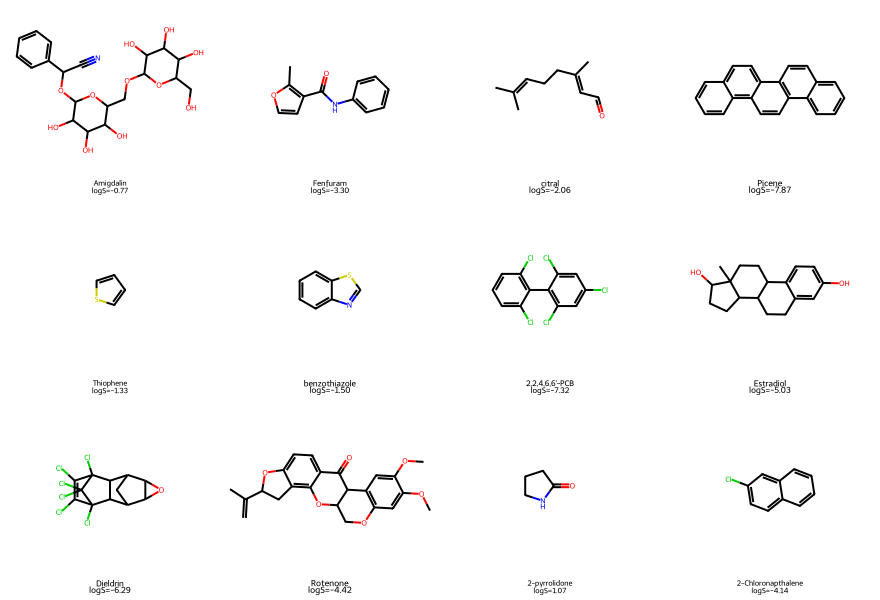

In [14]:
# ---------------------------------------------------------------------------
# Optional: render a few molecules with RDKit
# ---------------------------------------------------------------------------
from rdkit import Chem
from rdkit.Chem import Draw
mols   = [Chem.MolFromSmiles(s) for s in df["smiles"].head(12)]
labels = [f"{cid}\nlogS={ls:.2f}"
           for cid, ls in zip(df["Compound ID"].head(12),
                              df["measured log solubility in mols per litre"].head(12))]
img = Draw.MolsToGridImage(mols, molsPerRow=4, subImgSize=(220, 200), legends=labels)
img

In [18]:
"""
Drug Discovery with Graph Neural Networks — solubility prediction on Delaney
============================================================================

Pure PyTorch / PyTorch-Geometric port of `delaney_solubility_gnn.py`.

Replaces:
  - dc.molnet.load_delaney        -> torch_geometric.datasets.MoleculeNet("ESOL")
  - DeepChem's GraphConvModel     -> hand-written GCN in torch.nn
  - dc.trans.NormalizationTransformer -> in-script z-score normalization
  - dc.metrics                    -> sklearn + scipy

Workflow:
  1. Loads ESOL (Delaney) via PyG's MoleculeNet — molecules are pre-featurized
     into PyG `Data` objects (9-dim OGB-style atomic features, 3-dim bond feats).
  2. Random 80/10/10 split.
  3. Trains a 3-layer GCN with mean-pool readout for regression.
  4. Reports Pearson R, R^2, RMSE on train / valid / test.
  5. Saves parity plot, predictions CSV, and model weights.
  6. Predicts logS for aspirin / caffeine / benzene.

Requirements:
  pip install torch torch_geometric rdkit
  pip install scikit-learn pandas matplotlib scipy
"""

# ---------------------------------------------------------------------------
# 0. Configuration
# ---------------------------------------------------------------------------
import os

N_EPOCHS      = 100
BATCH_SIZE    = 64
LEARNING_RATE = 1e-3
HIDDEN_DIM    = 64
DROPOUT       = 0.2
OUTPUT_DIR    = "./delaney_gnn_run_torch"
DATA_DIR      = "./data/MoleculeNet"
SEED          = 42

os.makedirs(OUTPUT_DIR, exist_ok=True)

In [19]:
# ---------------------------------------------------------------------------
# 1. Imports
# ---------------------------------------------------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import random_split

from torch_geometric.datasets import MoleculeNet
from torch_geometric.loader import DataLoader
from torch_geometric.data import Batch
from torch_geometric.nn import GCNConv, global_mean_pool
from torch_geometric.utils import from_smiles

from sklearn.metrics import mean_squared_error, r2_score
from scipy.stats import pearsonr

torch.manual_seed(SEED)
np.random.seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"PyTorch version : {torch.__version__}")
print(f"Using device    : {device}")



PyTorch version : 2.5.1+cu121
Using device    : cuda


In [20]:
# ---------------------------------------------------------------------------
# 2. Load Delaney/ESOL
# ---------------------------------------------------------------------------
dataset = MoleculeNet(root=DATA_DIR, name="ESOL")
print(f"\nDataset         : {dataset}")
print(f"Num molecules   : {len(dataset)}")
print(f"Atom feat dim   : {dataset.num_node_features}")
print(f"Edge feat dim   : {dataset.num_edge_features}")

# Compute target normalization (z-score)
y_all = torch.cat([d.y for d in dataset]).view(-1).float()
y_mean = y_all.mean().item()
y_std  = y_all.std().item()
print(f"y mean / std    : {y_mean:.4f} / {y_std:.4f}")




Dataset         : ESOL(1128)
Num molecules   : 1128
Atom feat dim   : 9
Edge feat dim   : 3
y mean / std    : -3.0501 / 2.0964


In [21]:
# ---------------------------------------------------------------------------
# 3. Random 80 / 10 / 10 split
# ---------------------------------------------------------------------------
n         = len(dataset)
n_train   = int(0.8 * n)
n_valid   = int(0.1 * n)
n_test    = n - n_train - n_valid
generator = torch.Generator().manual_seed(SEED)
train_ds, valid_ds, test_ds = random_split(
    dataset, [n_train, n_valid, n_test], generator=generator
)
print(f"\nSplits          : train={len(train_ds)}  valid={len(valid_ds)}  test={len(test_ds)}")

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
valid_loader = DataLoader(valid_ds, batch_size=BATCH_SIZE)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE)




Splits          : train=902  valid=112  test=114


In [22]:
# ---------------------------------------------------------------------------
# 4. Model — 3-layer GCN + mean pool + 2-layer MLP head
# ---------------------------------------------------------------------------
class GCNRegressor(nn.Module):
    def __init__(self, in_dim, hidden_dim=64, out_dim=1, dropout=0.2):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.conv2 = GCNConv(hidden_dim, hidden_dim)
        self.conv3 = GCNConv(hidden_dim, hidden_dim)
        self.bn1   = nn.BatchNorm1d(hidden_dim)
        self.bn2   = nn.BatchNorm1d(hidden_dim)
        self.bn3   = nn.BatchNorm1d(hidden_dim)
        self.lin1  = nn.Linear(hidden_dim, hidden_dim)
        self.lin2  = nn.Linear(hidden_dim, out_dim)
        self.dropout = dropout

    def forward(self, x, edge_index, batch):
        x = F.relu(self.bn1(self.conv1(x, edge_index)))
        x = F.relu(self.bn2(self.conv2(x, edge_index)))
        x = F.relu(self.bn3(self.conv3(x, edge_index)))
        x = global_mean_pool(x, batch)                      # graph-level vector
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = F.relu(self.lin1(x))
        x = F.dropout(x, p=self.dropout, training=self.training)
        x = self.lin2(x)
        return x.squeeze(-1)


model     = GCNRegressor(in_dim=dataset.num_node_features,
                         hidden_dim=HIDDEN_DIM,
                         dropout=DROPOUT).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
loss_fn   = nn.MSELoss()
print(f"\n{model}")

# the model. GCNRegressor is a 3-layer GCN:
# three GCNConv layers (in_dim → hidden → hidden → hidden), each followed by BatchNorm1d and ReLU,
# global_mean_pool to collapse the node embeddings into one vector per molecule,
# dropout → Linear → ReLU → Linear → 1 MLP head.


GCNRegressor(
  (conv1): GCNConv(9, 64)
  (conv2): GCNConv(64, 64)
  (conv3): GCNConv(64, 64)
  (bn1): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (bn3): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (lin1): Linear(in_features=64, out_features=64, bias=True)
  (lin2): Linear(in_features=64, out_features=1, bias=True)
)


In [23]:
# ---------------------------------------------------------------------------
# 5. Train / evaluate
# ---------------------------------------------------------------------------
def train_one_epoch(loader):
    model.train()
    total_loss = 0.0
    for data in loader:
        data = data.to(device)
        y = (data.y.view(-1).float() - y_mean) / y_std       # normalize target
        optimizer.zero_grad()
        out  = model(data.x.float(), data.edge_index, data.batch)
        loss = loss_fn(out, y)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * data.num_graphs
    return total_loss / len(loader.dataset)


@torch.no_grad()
def evaluate(loader):
    model.eval()
    preds, trues = [], []
    for data in loader:
        data = data.to(device)
        out  = model(data.x.float(), data.edge_index, data.batch)
        pred = out.cpu().numpy() * y_std + y_mean             # un-normalize
        true = data.y.view(-1).cpu().numpy()
        preds.append(pred)
        trues.append(true)
    preds = np.concatenate(preds)
    trues = np.concatenate(trues)
    rmse  = float(np.sqrt(mean_squared_error(trues, preds)))
    r2    = float(r2_score(trues, preds))
    rho   = float(pearsonr(trues, preds)[0])
    return rmse, r2, rho, preds, trues


print(f"\nTraining for {N_EPOCHS} epochs ...")
history = []
for epoch in range(1, N_EPOCHS + 1):
    train_loss = train_one_epoch(train_loader)
    if epoch == 1 or epoch % 10 == 0:
        v_rmse, v_r2, v_rho, _, _ = evaluate(valid_loader)
        print(f"  epoch {epoch:3d}  train_loss = {train_loss:.4f}   "
              f"val_RMSE = {v_rmse:.3f}   val_R^2 = {v_r2:.3f}   "
              f"val_rho = {v_rho:.3f}")
        history.append((epoch, train_loss, v_rmse, v_r2, v_rho))




Training for 100 epochs ...
  epoch   1  train_loss = 0.9410   val_RMSE = 2.217   val_R^2 = 0.052   val_rho = 0.520
  epoch  10  train_loss = 0.2580   val_RMSE = 1.218   val_R^2 = 0.714   val_rho = 0.888
  epoch  20  train_loss = 0.2013   val_RMSE = 1.030   val_R^2 = 0.795   val_rho = 0.909
  epoch  30  train_loss = 0.1969   val_RMSE = 0.900   val_R^2 = 0.844   val_rho = 0.922
  epoch  40  train_loss = 0.1823   val_RMSE = 0.896   val_R^2 = 0.845   val_rho = 0.927
  epoch  50  train_loss = 0.1881   val_RMSE = 1.043   val_R^2 = 0.790   val_rho = 0.926
  epoch  60  train_loss = 0.1748   val_RMSE = 0.960   val_R^2 = 0.822   val_rho = 0.934
  epoch  70  train_loss = 0.1558   val_RMSE = 0.922   val_R^2 = 0.836   val_rho = 0.924
  epoch  80  train_loss = 0.1555   val_RMSE = 0.854   val_R^2 = 0.859   val_rho = 0.932
  epoch  90  train_loss = 0.1440   val_RMSE = 0.829   val_R^2 = 0.867   val_rho = 0.938
  epoch 100  train_loss = 0.1323   val_RMSE = 0.802   val_R^2 = 0.876   val_rho = 0.942


In [24]:
# ---------------------------------------------------------------------------
# 6. Final metrics on all splits
# ---------------------------------------------------------------------------
print("\n=== Final metrics ===")
for name, loader in [("Train",      train_loader),
                     ("Validation", valid_loader),
                     ("Test",       test_loader)]:
    rmse, r2, rho, _, _ = evaluate(loader)
    print(f"{name:>12}   R^2 = {r2:.4f}   rho = {rho:.4f}   RMSE = {rmse:.4f}")


# ---------------------------------------------------------------------------
# 7. Parity plot on the test set
# ---------------------------------------------------------------------------
test_rmse, test_r2, test_rho, y_pred, y_true = evaluate(test_loader)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_true, y_pred, alpha=0.6, s=18)
lo = float(min(y_true.min(), y_pred.min()))
hi = float(max(y_true.max(), y_pred.max()))
ax.plot([lo, hi], [lo, hi], "k--", lw=1)
ax.set_xlabel("True log solubility")
ax.set_ylabel("Predicted log solubility")
ax.set_title(
    f"Delaney (PyTorch GCN) — Test parity plot\n"
    f"R^2 = {test_r2:.3f}   rho = {test_rho:.3f}   RMSE = {test_rmse:.3f}"
)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "parity_test.png"), dpi=150)
plt.close(fig)




=== Final metrics ===
       Train   R^2 = 0.9067   rho = 0.9593   RMSE = 0.6342
  Validation   R^2 = 0.8760   rho = 0.9424   RMSE = 0.8016
        Test   R^2 = 0.9030   rho = 0.9555   RMSE = 0.6380


In [25]:

# ---------------------------------------------------------------------------
# 8. Save predictions + model
# ---------------------------------------------------------------------------
# Recover the SMILES strings for the molecules that landed in the test split.
# PyG's MoleculeNet stores them on each Data object as `.smiles`.
test_smiles = []
for idx in test_ds.indices:
    d = dataset[idx]
    test_smiles.append(getattr(d, "smiles", ""))

df = pd.DataFrame({
    "smiles":         test_smiles,
    "true_logS":      y_true,
    "predicted_logS": y_pred,
    "abs_error":      np.abs(y_true - y_pred),
})
df.to_csv(os.path.join(OUTPUT_DIR, "test_predictions.csv"), index=False)

torch.save(
    {
        "model_state_dict": model.state_dict(),
        "config": {
            "in_dim":     dataset.num_node_features,
            "hidden_dim": HIDDEN_DIM,
            "dropout":    DROPOUT,
            "y_mean":     y_mean,
            "y_std":      y_std,
        },
    },
    os.path.join(OUTPUT_DIR, "gcn_delaney.pt"),
)

print(f"\nSaved predictions -> {OUTPUT_DIR}/test_predictions.csv")
print(f"Saved parity plot -> {OUTPUT_DIR}/parity_test.png")
print(f"Saved model       -> {OUTPUT_DIR}/gcn_delaney.pt")




Saved predictions -> ./delaney_gnn_run_torch/test_predictions.csv
Saved parity plot -> ./delaney_gnn_run_torch/parity_test.png
Saved model       -> ./delaney_gnn_run_torch/gcn_delaney.pt


In [26]:
# ---------------------------------------------------------------------------
# 9. Predict solubility for custom SMILES
# ---------------------------------------------------------------------------
custom_smiles = [
    "CC(=O)Oc1ccccc1C(=O)O",         # aspirin
    "CN1C=NC2=C1C(=O)N(C(=O)N2C)C",  # caffeine
    "C1=CC=CC=C1",                   # benzene
]

# `from_smiles` uses the same 9-dim OGB-style atomic features as MoleculeNet,
# so the model trained on ESOL accepts these graphs directly.
custom_data = [from_smiles(s) for s in custom_smiles]
batch = Batch.from_data_list(custom_data).to(device)

model.eval()
with torch.no_grad():
    out = model(batch.x.float(), batch.edge_index, batch.batch).cpu().numpy()
    pred_custom = out * y_std + y_mean

print("\nPredictions on custom molecules:")
for smi, p in zip(custom_smiles, pred_custom):
    print(f"  {smi:<40s}  predicted logS = {p:.3f}")


Predictions on custom molecules:
  CC(=O)Oc1ccccc1C(=O)O                     predicted logS = -2.110
  CN1C=NC2=C1C(=O)N(C(=O)N2C)C              predicted logS = -1.575
  C1=CC=CC=C1                               predicted logS = -2.003


In [28]:
print('''

About F1 - score : 

F1 is a classification metric (harmonic mean of precision and recall over discrete labels), 
so it doesn't apply directly to your model — the Delaney pipeline you have is a regression problem predicting a continuous logS value. 
There is no notion of "true positive" until you decide what counts as a positive class.

You have two options.

Option 1 — Binarize logS into a "soluble / insoluble" label
Pick a logS cutoff (a common one in medicinal-chemistry papers is logS = −4, the boundary between drug-like solubility and poorly soluble) 
and call anything above it "soluble" (1) and anything below it "insoluble" (0). Then F1 makes sense.

Option 2 — Multi-bin "very soluble / soluble / poor / insoluble" classification
If a single threshold feels arbitrary, bin logS into 3 or 4 categories and compute multiclass F1 ...

''')




About F1 - score : 

F1 is a classification metric (harmonic mean of precision and recall over discrete labels), 
so it doesn't apply directly to your model — the Delaney pipeline you have is a regression problem predicting a continuous logS value. 
There is no notion of "true positive" until you decide what counts as a positive class.

You have two options.

Option 1 — Binarize logS into a "soluble / insoluble" label
Pick a logS cutoff (a common one in medicinal-chemistry papers is logS = −4, the boundary between drug-like solubility and poorly soluble) 
and call anything above it "soluble" (1) and anything below it "insoluble" (0). Then F1 makes sense.

Option 2 — Multi-bin "very soluble / soluble / poor / insoluble" classification
If a single threshold feels arbitrary, bin logS into 3 or 4 categories and compute multiclass F1 ...




In [ ]:
# To visualize the TEST, VALIDATE, and TRAIN datasets :

In [29]:
import pandas as pd
from rdkit import Chem
from rdkit.Chem import Draw

def subset_to_df(subset, name):
    """Return a DataFrame with the SMILES and logS for every molecule in a subset."""
    rows = []
    for local_i, ds_idx in enumerate(subset.indices):
        d = dataset[ds_idx]
        rows.append({
            "split":        name,
            "subset_idx":   local_i,        # position inside train/valid/test
            "dataset_idx":  ds_idx,         # position in the full ESOL dataset
            "smiles":       d.smiles,
            "logS":         float(d.y),
            "num_atoms":    d.num_nodes,
            "num_bonds":    d.num_edges // 2,
        })
    return pd.DataFrame(rows)

train_df = subset_to_df(train_ds, "train")
valid_df = subset_to_df(valid_ds, "valid")
test_df  = subset_to_df(test_ds,  "test")

print(f"train: {len(train_df)} molecules")
print(f"valid: {len(valid_df)} molecules")
print(f"test : {len(test_df)} molecules")

# Save them to disk so you can browse outside Python
train_df.to_csv("delaney_train_molecules.csv", index=False)
valid_df.to_csv("delaney_valid_molecules.csv", index=False)
test_df.to_csv("delaney_test_molecules.csv",  index=False)

train: 902 molecules
valid: 112 molecules
test : 114 molecules


In [30]:
print("\n=== TRAIN (first 10 rows) ===")
print(train_df.head(10).to_string(index=False))

print("\n=== VALID (first 10 rows) ===")
print(valid_df.head(10).to_string(index=False))

print("\n=== TEST  (first 10 rows) ===")
print(test_df.head(10).to_string(index=False))


=== TRAIN (first 10 rows) ===
split  subset_idx  dataset_idx                                           smiles   logS  num_atoms  num_bonds
train           0          126                         CCCCc1c(C)nc(nc1O)N(C)C  -2.240         15         15
train           1          360     CN(C)C(=O)Nc1ccc(c(Cl)c1)n2nc(oc2=O)C(C)(C)C -4.328         23         24
train           2         1014                        O=C1NCCN1c2ncc(s2)N(=O)=O -3.220         14         15
train           3         1042            Clc1cc(Cl)c(cc1Cl)c2cc(Cl)c(Cl)cc2Cl  -8.560         18         19
train           4          210                                        CCOC(=O)C -0.040          6          5
train           5          645                               Brc1cc(Br)cc(Br)c1 -5.600          9          9
train           6          790     c1cc(O)c(O)c2OCC3(O)CC4=CC(=O)C(O)=CC4=C3c21 -2.700         22         25
train           7          697                                    CCc1ccc(C)cc1 -3.110          9